# Урок 5.1. Функциональный градиент и псевдо-остатки

**Интерактивная версия:** `lessons/lesson_5_1/web/index.html`

1. Градиент риска по вектору прогнозов — проверка численным дифференцированием.
2. Свободный спуск против шага деревом.
3. Косинус между градиентом и деревом по итерациям.
4. Псевдо-остатки для разных потерь.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from gbcourse import datasets, RegressionTree, get_loss
from gbcourse.plotting import use_course_style

use_course_style()

## 1. Градиент риска по прогнозам

$R(\mathbf F) = \frac1n\sum_i L(y_i, F_i)$, $\;\partial R/\partial F_i = \frac1n g_i$. Проверим разностной схемой.

In [2]:
X, y = datasets.regression_1d(kind="sine", n=40, noise=0.3, seed=52)
F = np.full_like(y, 0.1)
for name, kw in [("squared", {}), ("huber", {"delta": 0.5}), ("logistic", {})]:
    loss = get_loss(name, **kw)
    yy = (y > 0).astype(float) if name == "logistic" else y
    R = lambda F, loss=loss, yy=yy: loss.loss(yy, F)
    eps = 1e-6
    i = 7
    Fp, Fm = F.copy(), F.copy()
    Fp[i] += eps
    Fm[i] -= eps
    print(f"{name:9s}: численно {(R(Fp) - R(Fm)) / (2 * eps):+.6f}, формула g_i/n = {loss.gradient(yy, F)[i] / len(y):+.6f}")

squared  : численно -0.020156, формула g_i/n = -0.020156
huber    : численно -0.012500, формула g_i/n = -0.012500
logistic : численно -0.011876, формула g_i/n = -0.011876


## 2. Свободный спуск против шага деревом

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


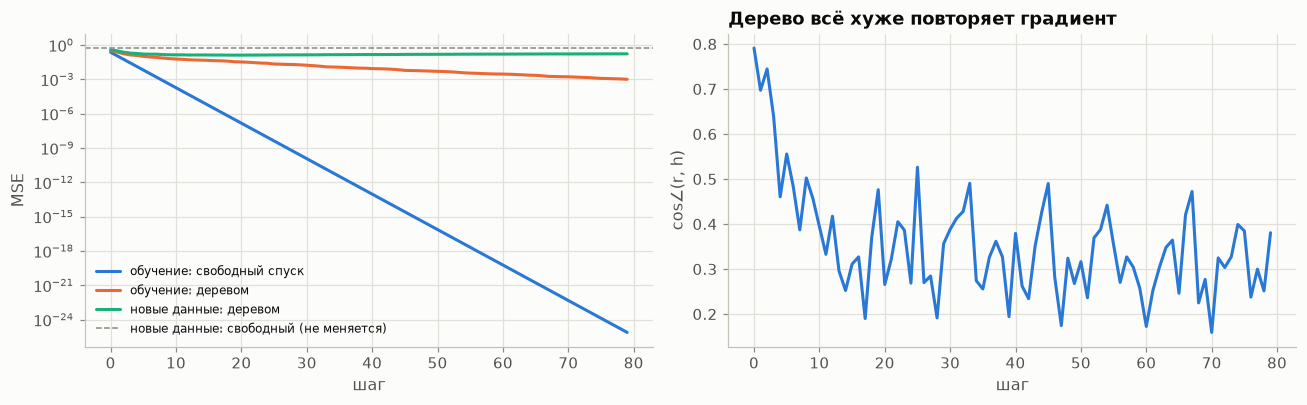

In [3]:
X_te, y_te = datasets.regression_1d(kind="sine", n=2000, noise=0.3, seed=53)
nu = 0.3
F_free = np.full_like(y, y.mean())
F_tree, F_te = F_free.copy(), np.full(len(y_te), y.mean())
hist, cosines = [], []
for _ in range(80):
    F_free += nu * (y - F_free)
    r = y - F_tree
    h = RegressionTree(max_depth=2).fit(X, -r)
    hv = h.predict(X)
    cosines.append(r @ hv / (np.linalg.norm(r) * np.linalg.norm(hv) + 1e-12))
    F_tree += nu * hv
    F_te += nu * h.predict(X_te)
    hist.append((np.mean((y - F_free) ** 2), np.mean((y - F_tree) ** 2), np.mean((y_te - F_te) ** 2)))
hist = np.array(hist)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(hist[:, 0], label="обучение: свободный спуск")
axes[0].plot(hist[:, 1], label="обучение: деревом")
axes[0].plot(hist[:, 2], label="новые данные: деревом")
axes[0].axhline(np.mean((y_te - y.mean()) ** 2), color="#898781", ls="--", lw=1, label="новые данные: свободный (не меняется)")
axes[0].set(xlabel="шаг", ylabel="MSE", yscale="log")
axes[0].legend(fontsize=8)
axes[1].plot(cosines)
axes[1].set(xlabel="шаг", ylabel="cos∠(r, h)", title="Дерево всё хуже повторяет градиент")
plt.tight_layout()
plt.show()

## 3. Псевдо-остатки разных потерь при одном и том же F

In [4]:
r_grid = np.linspace(-3, 3, 7)
for name, kw in [("squared", {}), ("absolute", {}), ("huber", {"delta": 1.0}), ("quantile", {"alpha": 0.9})]:
    loss = get_loss(name, **kw)
    print(f"{name:9s}:", np.round(loss.negative_gradient(r_grid, np.zeros_like(r_grid)), 2))
print("остатки y − F:", r_grid)

squared  : [-3. -2. -1. -0.  1.  2.  3.]
absolute : [-1. -1. -1. -0.  1.  1.  1.]
huber    : [-1. -1. -1.  0.  1.  1.  1.]
quantile : [-0.1 -0.1 -0.1  0.9  0.9  0.9  0.9]
остатки y − F: [-3. -2. -1.  0.  1.  2.  3.]


## Упражнения

1. Выведите псевдо-остатки потерь $L = \log\cosh(y - F)$ и проверьте численно.
2. Докажите: для L2 и дерева с листьями-средними $\langle r, h\rangle = \|h\|^2$.
3. Постройте cos∠(r, h) по итерациям для глубин 1, 3, 6. Как глубина влияет на качество проекции?

Решения: `python lessons/lesson_5_1/exercises/solutions.py`.